# XAI sobre CartPole-v1 con A2C
Entrenamos un agente A2C sobre CartPole-v1 y luego lo explicamos con SHAP y un árbol de decisión sustituto.

In [1]:
FEATURE_NAMES = [
    "pos_carro",       # posición horizontal del carro
    "vel_carro",       # velocidad horizontal del carro
    "angulo_palo",     # ángulo del palo respecto a la vertical
    "vel_ang_palo",    # velocidad angular del palo
]

ACTION_NAMES = [
    "izquierda",   # 0: empujar carro a la izquierda
    "derecha",     # 1: empujar carro a la derecha
]

In [2]:
import numpy as np
import gymnasium as gym
from stable_baselines3 import A2C
from stable_baselines3.common.callbacks import EvalCallback
import shap
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import torch
from matplotlib import animation
from IPython.display import HTML
from visualization import show_animation_with_decision_path



c:\Users\Nitropc\Desktop\UCM\MIA\XRL\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Entrenamiento del agente A2C

In [3]:
# Cargamos el mejor modelo guardado por EvalCallback
best_model = A2C.load("best_model")
print("Mejor modelo cargado.")

Mejor modelo cargado.


c:\Users\Nitropc\Desktop\UCM\MIA\XRL\.venv\Lib\site-packages\stable_baselines3\common\on_policy_algorithm.py:150: UserWarning: You are trying to run A2C on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


## 2. Evaluación del agente

In [4]:
def evaluar_politica_modelo(model, n_episodes=20, deterministic=True):
    env = gym.make("CartPole-v1")
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action, _ = model.predict(obs, deterministic=deterministic)
            obs, r, term, trunc, _ = env.step(int(action))
            total += r
            done = term or trunc
        rewards.append(total)
    env.close()
    return np.mean(rewards), np.std(rewards)

m, s = evaluar_politica_modelo(best_model)
print(f"Recompensa del A2C: {m:.1f} ± {s:.1f}")

Recompensa del A2C: 500.0 ± 0.0


## 3. Recolección del dataset de comportamiento

In [5]:
X = np.load("datos/X_cartpole.npy")
y = np.load("datos/y_cartpole.npy")

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 4. Explicabilidad con SHAP (KernelExplainer)

In [7]:
def politica_proba(obs_batch):
    """Devuelve la distribución de probabilidad sobre acciones para un batch de observaciones."""
    device = best_model.policy.device
    obs_t = torch.as_tensor(obs_batch, dtype=torch.float32, device=device)
    dist = best_model.policy.get_distribution(obs_t)
    probs = dist.distribution.probs.detach().cpu().numpy()
    return probs[:, 1]

explainer = shap.KernelExplainer(politica_proba, shap.sample(X_train, 10000))
shap_values = explainer.shap_values(X_test[:500])
print("SHAP values calculados. Tipo:", type(shap_values))

Using 10000 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
100%|██████████| 500/500 [00:02<00:00, 180.57it/s]

SHAP values calculados. Tipo: <class 'numpy.ndarray'>


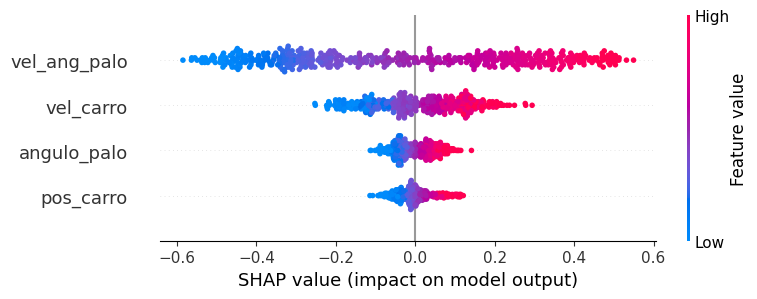

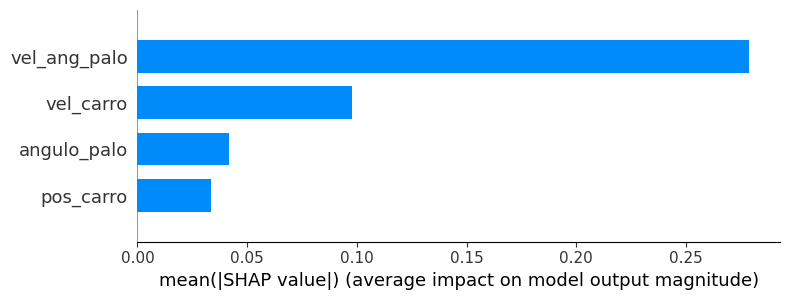

In [8]:
shap.summary_plot(shap_values, X_test[:500], feature_names=FEATURE_NAMES)
shap.summary_plot(shap_values, X_test[:500], feature_names=FEATURE_NAMES, plot_type="bar")

## 5. Árbol de decisión sustituto

In [9]:
# max_depth controla el trade-off entre fidelidad e interpretabilidad
tree = DecisionTreeClassifier(max_depth=6, random_state=42)
tree.fit(X_train, y_train)

print(f"Fidelidad (accuracy vs A2C): {accuracy_score(y_test, tree.predict(X_test)):.3f}")
print(classification_report(y_test, tree.predict(X_test), target_names=ACTION_NAMES))

Fidelidad (accuracy vs A2C): 0.965
              precision    recall  f1-score   support

   izquierda       0.96      0.97      0.96      9998
     derecha       0.97      0.96      0.96     10002

    accuracy                           0.96     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.96      0.96      0.96     20000



In [10]:
# Barrido de profundidades para elegir el mejor trade-off
for d in [2, 3, 4, 5, 6, 8, 10, 15, 20]:
    t = DecisionTreeClassifier(max_depth=d, random_state=42).fit(X_train, y_train)
    print(f"depth={d:2d}  fidelidad={accuracy_score(y_test, t.predict(X_test)):.3f}")

depth= 2  fidelidad=0.892
depth= 3  fidelidad=0.942
depth= 4  fidelidad=0.948
depth= 5  fidelidad=0.956
depth= 6  fidelidad=0.965
depth= 8  fidelidad=0.978
depth=10  fidelidad=0.984
depth=15  fidelidad=0.985
depth=20  fidelidad=0.984


|--- vel_ang_palo <= 0.00
|   |--- vel_ang_palo <= -0.09
|   |   |--- vel_ang_palo <= -0.13
|   |   |   |--- vel_ang_palo <= -0.15
|   |   |   |   |--- vel_carro <= 0.58
|   |   |   |   |   |--- vel_ang_palo <= -0.16
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- vel_ang_palo >  -0.16
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- vel_carro >  0.58
|   |   |   |   |   |--- vel_ang_palo <= -0.17
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- vel_ang_palo >  -0.17
|   |   |   |   |   |   |--- class: 1
|   |   |   |--- vel_ang_palo >  -0.15
|   |   |   |   |--- vel_carro <= 0.40
|   |   |   |   |   |--- pos_carro <= -0.03
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- pos_carro >  -0.03
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- vel_carro >  0.40
|   |   |   |   |   |--- angulo_palo <= -0.01
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- angulo_palo >  -0.01
|   |   |   |   |   |   |--- class: 1
| 

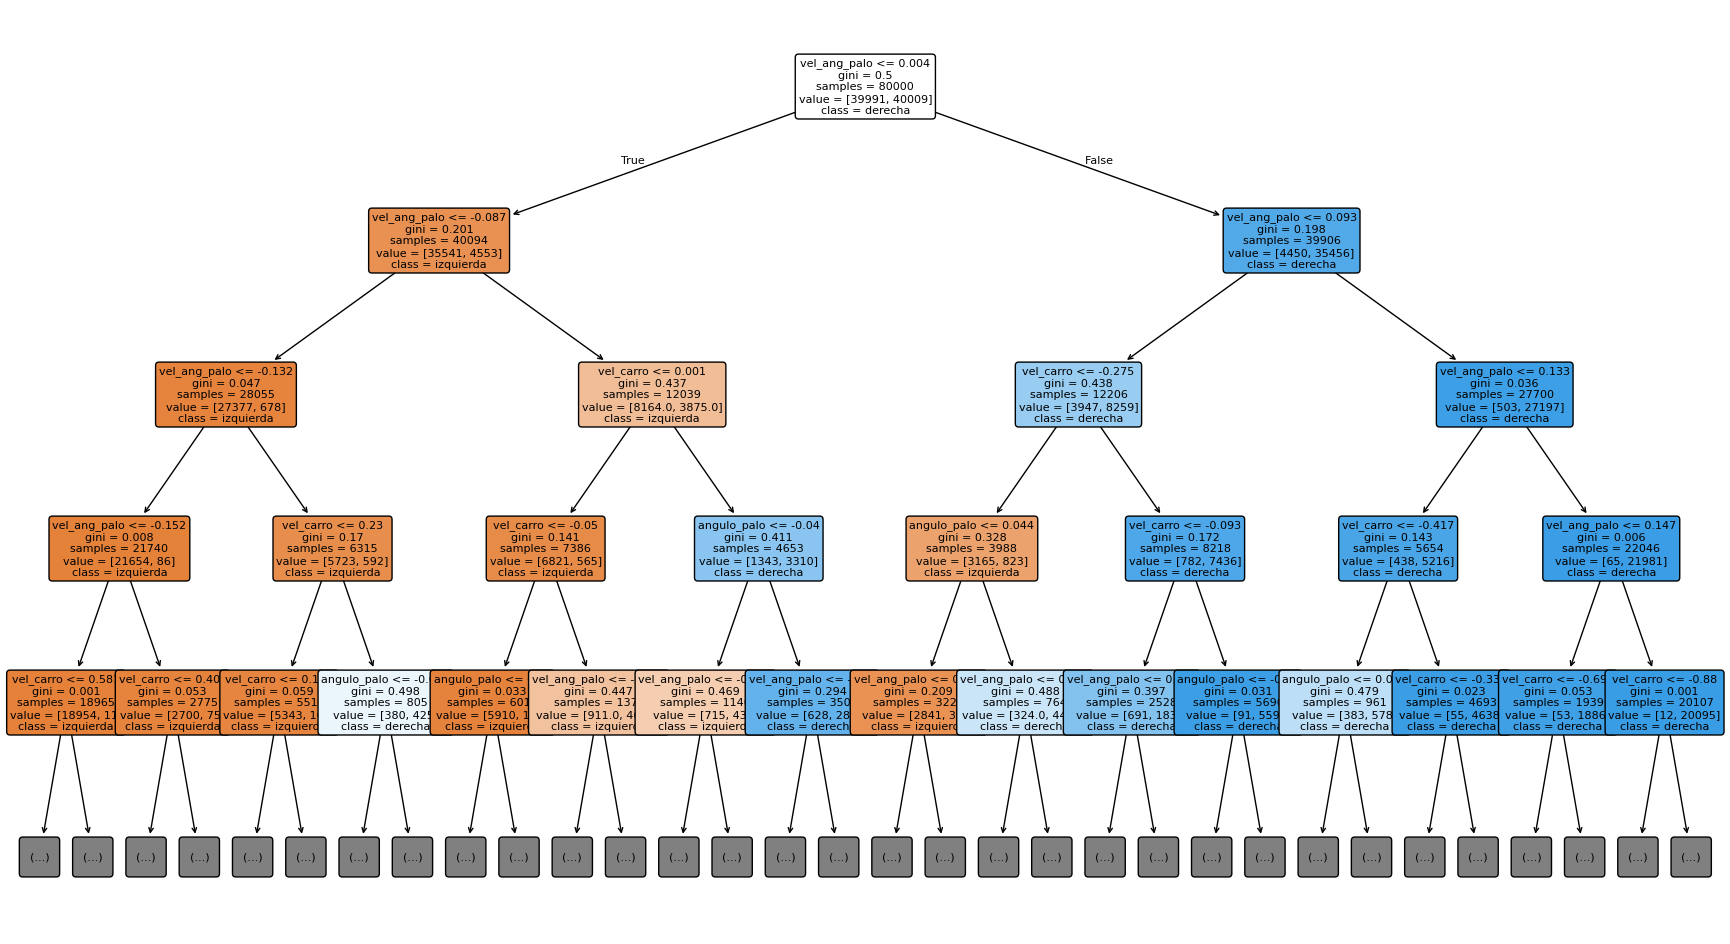

In [11]:
# Reglas legibles en texto
print(export_text(tree, feature_names=FEATURE_NAMES))

# Árbol gráfico
plt.figure(figsize=(22, 12))
plot_tree(
    tree,
    feature_names=FEATURE_NAMES,
    class_names=ACTION_NAMES,
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=4,  # recorta el dibujo para que sea legible
)
plt.savefig("arbol_cartpole.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Evaluación del árbol como política

In [12]:
def evaluar_politica_arbol(tree, n_episodes=20):
    env = gym.make("CartPole-v1")
    rewards = []
    for _ in range(n_episodes):
        obs, _ = env.reset()
        done, total = False, 0.0
        while not done:
            action = int(tree.predict(obs.reshape(1, -1))[0])
            obs, r, term, trunc, _ = env.step(action)
            total += r
            done = term or trunc
        rewards.append(total)
    env.close()
    return np.mean(rewards), np.std(rewards)

m, s = evaluar_politica_arbol(tree)
print(f"Recompensa del árbol sustituto: {m:.1f} ± {s:.1f}")

Recompensa del árbol sustituto: 493.1 ± 30.3


## 7. Importancia de características según el árbol

vel_ang_palo    0.781730
vel_carro       0.178079
angulo_palo     0.029018
pos_carro       0.011174
dtype: float64


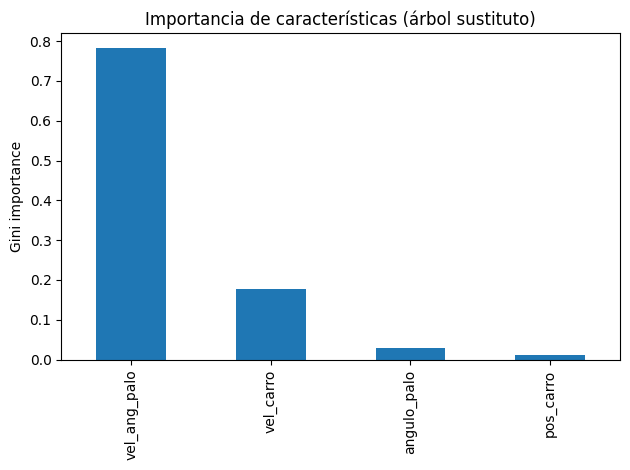

In [13]:
imp = pd.Series(tree.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
print(imp)

imp.plot(kind="bar", title="Importancia de características (árbol sustituto)", ylabel="Gini importance")
plt.tight_layout()
plt.savefig("importancia_cartpole.png", dpi=150)
plt.show()

In [14]:
def explain_action_tree(state, tree, feature_names):
    node_ids = tree.decision_path(state.reshape(1, -1)).indices
    rules = []
    for node in node_ids[:-1]:
        feat = feature_names[tree.tree_.feature[node]]
        thr = tree.tree_.threshold[node]
        val = state[tree.tree_.feature[node]]
        rules.append((feat, "<=" if val <= thr else ">", thr, val))

    action_taken = tree.predict(state.reshape(1, -1))[0]
    return action_taken, rules

In [15]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
frames, explanations = [], []
state, _ = env.reset()
state = np.array(state, dtype=np.float32)
done = False

while not done:
    frames.append(env.render())
    action, _ = best_model.predict(state, deterministic=True)
    action_taken, rules = explain_action_tree(state,tree, FEATURE_NAMES)
    explanations.append({"action": ACTION_NAMES[action], "rules": rules})
    state, reward, terminated, truncated, _ = env.step(action)
    state = np.array(state, dtype=np.float32)
    done = terminated or truncated

env.close()

c:\Users\Nitropc\Desktop\UCM\MIA\XRL\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [16]:
ani = show_animation_with_decision_path(frames[:10], explanations[:10])

HTML(ani.to_jshtml())